In [59]:
%%writefile cellular_periodic.c

#include <mpi.h>
#include <stdio.h>
#include <stdlib.h>
#include <time.h>
#include <string.h>

//Length of the stirng
static const int N = 100;//40000000;

//Number of iterations
static const int Nit = 10000;//10;

int main(int argc, char ** argv)
{
    int r = atoi(argv[1]);
    int rule[] = {0, 1, 0, 0, 1, 0, 1, 1};
    int r1 = r;
    for (int i = 7; i>=0; i--){
        rule[i] = r1 / (1 << i);
        r1 -= (r1/(1 << i)) * (1 << i);
    }

    int psize;
    int prank;
    MPI_Status status;

    int ierr;

    ierr = MPI_Init(&argc, &argv);
    ierr = MPI_Comm_rank(MPI_COMM_WORLD, &prank);
    ierr = MPI_Comm_size(MPI_COMM_WORLD, &psize);

    MPI_File_delete(argv[2], MPI_INFO_NULL);

    MPI_Barrier(MPI_COMM_WORLD);
    double t1, t2;
    t1 = MPI_Wtime();

    srand (time(NULL) +  prank);

    MPI_Request request;
    MPI_File fh;
    int rc = MPI_File_open(MPI_COMM_WORLD, argv[2], MPI_MODE_CREATE|MPI_MODE_EXCL|MPI_MODE_WRONLY, MPI_INFO_NULL, &fh);
    int sizeRank = N/psize + ((prank+1)/(N%psize+1) == 0 ? 1 : 0);

    //Size of the chunk corresponded to the thread
    MPI_Offset offset = sizeRank*prank;
    int sizeRow = sizeRank + 2;
    int charSize = sizeRank + (prank==(psize-1));

    char* buf = (char*)malloc(charSize * sizeof(char));
    if (prank == (psize-1))
        buf[charSize-1] = '\n';
    int* row = (int*)malloc(sizeRow * sizeof(int));
    for(int i = 1; i < sizeRow -1; i++)
        row[i] = rand()%2;

    int* rowChanged = (int*)malloc(sizeRow * sizeof(int));


    for (int j = 0; j<Nit; j++){
        if (psize>1)
        {
            //Boundary conditions
            if (prank == 0){
                MPI_Isend(row+1, 1, MPI_INT, psize-1, 1, MPI_COMM_WORLD, &request);
                MPI_Isend(row+sizeRow-2, 1, MPI_INT, 1, 0, MPI_COMM_WORLD, &request);
            } else if (prank == psize - 1){
                MPI_Isend(row+1, 1, MPI_INT, psize-2, 1, MPI_COMM_WORLD, &request);
                MPI_Isend(row+sizeRow-2, 1, MPI_INT, 0, 0, MPI_COMM_WORLD, &request);
            } else{
                MPI_Isend(row+1, 1, MPI_INT, prank-1, 1, MPI_COMM_WORLD, &request);
                MPI_Isend(row+sizeRow-2, 1, MPI_INT, prank + 1, 0, MPI_COMM_WORLD, &request);
            }
            MPI_Recv(row, 1, MPI_INT, MPI_ANY_SOURCE, 0, MPI_COMM_WORLD, &status);
            MPI_Recv(row + sizeRow - 1, 1, MPI_INT, MPI_ANY_SOURCE, 1, MPI_COMM_WORLD, &status);

            ierr =  MPI_Barrier(MPI_COMM_WORLD);
        }
        else{
            row[0] = row[sizeRow-2];
            row[sizeRow-1] = row[1];
        }

        //On step of the iteration with respect to the chink of the thread
        for (int i = 1; i < sizeRow - 1; i++){
            rowChanged[i] = rule[4 * row[i-1] + 2 * row[i] + row[i+1]];
        }
        for (int i = 1; i < sizeRow - 1; i++){
            row[i] = rowChanged[i];
            buf[i-1] = rowChanged[i] +'0';
        }

        //write to file
        MPI_File_write_at(fh, offset, buf, charSize, MPI_CHAR, MPI_STATUS_IGNORE);
        offset+=N+1;

        ierr =  MPI_Barrier(MPI_COMM_WORLD);
    }
    free(row);
    free(buf);
    free(rowChanged);
    MPI_File_close(&fh);
    t2 = MPI_Wtime();
    if (prank == 0)
        printf("MPI_Wtime: %1.4f\n", t2-t1);

    ierr = MPI_Finalize();
    return 0;
}

Overwriting cellular_periodic.c


In [60]:
!mpicc

gcc: fatal error: no input files
compilation terminated.


In [61]:
!mpicc cellular_periodic.c

In [62]:
!mpirun --allow-run-as-root -n 1 ./a.out 30 30.txt

MPI_Wtime: 0.0347


In [63]:
!mpirun --allow-run-as-root --oversubscribe -n 2 ./a.out 120 120.txt

MPI_Wtime: 0.0914


In [64]:
!mpirun --allow-run-as-root --oversubscribe -n 4 ./a.out 110 110.txt

MPI_Wtime: 0.2792


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def open_data(file):
    filename = open(file, "r")
    data = []
    gr = filename.readline().strip()
    while gr:
        gr = list(map(int,str(gr)))
        data.append(gr)
        gr = filename.readline().strip()
    data = np.array(data)
    return data

fig, ax = plt.subplots(1, 3, figsize = (15, 10))

data = open_data("120.txt")
ax[0].imshow(data, cmap='bone_r')
ax[0].set_title("Rule 120")

data = open_data("110.txt")
ax[1].imshow(data, cmap='bone_r')
ax[1].set_title("Rule 110")

data = open_data("30.txt")
ax[2].set_title("Rule 30")
ax[2].imshow(data, cmap='bone_r')

plt.show()

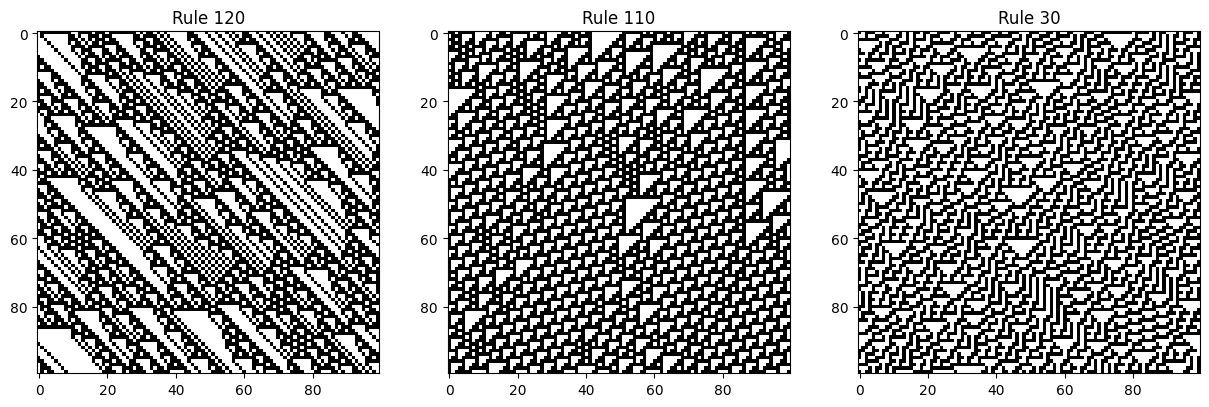

# 1. Проверить, что код, представленный выше работает на вашем компьютере

Код запущен в google colab. Были проблемы с запуском. Использовал флаги --allow-run-as-root и --oversubscribe. Возможно из-за второго распараллеливание не сработало  

Ниже выполнение кода с параметрами по умолчанию
```
1 процесс: time = 0.0019 (rule 30, файл 30.txt).  
2 процесса: time = 0.0047 (rule 120, файл 120.txt).  
4 процесса: time = 0.0196 (rule 110, файл 110.txt).  
```

Ниже с параметром Nit=10000
```
MPI_Wtime: 0.0347
MPI_Wtime: 0.0347
MPI_Wtime: 0.2792
```

# 2. Измерить время расчета на 1, 2, 4 mpi процессах. Виден ли прирост производительности, при использовании большего числа ядер? Что будет если поварьировать длину массива (параметр N)?
По текущим данным запусков видно, что время росло с увеличением числа процессов.
Ускорения не наблюдается.  
Скорее всего проблема с флагом -oversubscribe который позволяет запустить больше процессов несмотря на ограничение физических ядер.

# 3. Попробовать реализовать клеточный автомат на Python. Получится ли сделать код быстрее данной реализации в C? Можно писать код, используя любые инструменты (не только те, что были представлены на занятиях). Можно изпользовать логику, отличную от представленной в сишной реализации.




In [35]:
import numpy as np
import time
from numba import njit

In [38]:
@njit
def cellular_periodic(rule, N=100, Nit=100):
    rule_bits = np.zeros(8, dtype=np.uint8)
    for i in range(8):
        rule_bits[i] = (rule >> i) & 1

    row = np.random.randint(0, 2, size=N).astype(np.uint8)
    history = np.empty((Nit, N), dtype=np.uint8)

    for t in range(Nit):
        history[t] = row
        new_row = np.empty_like(row)
        for i in range(N):
            left  = row[(i-1) % N]
            mid   = row[i]
            right = row[(i+1) % N]
            idx = (left << 2) | (mid << 1) | right
            new_row[i] = rule_bits[idx]
        row = new_row
    return history

In [65]:
start = time.time()
history = cellular_periodic(30, 1000, 10000)
end = time.time()
print(f"Время выполнения: {end - start:.4f} сек")

Время выполнения: 0.0995 сек


In [66]:
start = time.time()
history = cellular_periodic(120, 2000, 10000)
end = time.time()
print(f"Время выполнения: {end - start:.4f} сек")

Время выполнения: 0.2092 сек


In [67]:
start = time.time()
history = cellular_periodic(110, 4000, 10000)
end = time.time()
print(f"Время выполнения: {end - start:.4f} сек")

Время выполнения: 0.4174 сек


## Результаты numba + python

* 1 прогон:
```
Время выполнения: 0.0056 сек
Время выполнения: 0.0109 сек
Время выполнения: 0.0211 сек
```
* 2 прогон N=10000
```
Время выполнения: 0.0995 сек
Время выполнения: 0.2092 сек
Время выполнения: 0.4174 сек
```
____________
## Главный вывод
Несмотря на использование флага --oversubscribe который по всей видимости немного тормозит обработку, связка пайтон и нумба значительно уступает С.

Можно еще провести тесты с cupy на мощностях видеокарты обработать.

________
* 1 прогон С
```
1 процесс: time = 0.0019 (rule 30, файл 30.txt).  
2 процесса: time = 0.0047 (rule 120, файл 120.txt).  
4 процесса: time = 0.0196 (rule 110, файл 110.txt).  
```
* 2 прогон С с параметром Nit=10000
```
MPI_Wtime: 0.0347
MPI_Wtime: 0.0347
MPI_Wtime: 0.2792
```